In [2]:
import numpy as np

In [3]:
! pwd

/Users/ycho/cell2mol/cell2mol/test


In [28]:
name = "XAWJUB"
refcell = np.load(f"{name}/Ref_Cell_{name}.cell", allow_pickle=True)
cell = np.load(f"{name}/Cell_{name}.cell", allow_pickle=True)

In [29]:
for spec in refcell.unique_species:
    if spec.subtype == "ligand":
        print(spec.charge_state)

------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                          = [H][C+]1[C-]([H])[C-]([H])C([H])([H])[C-]1[H]
 Charge Tried                    = -1
 Uncorrected Total Charge        = -2
 Corrected Total Charge          = -3
 Corrected Absolute Total Charge = 5
 Corrected Is Zwitterion?        = True
---------------------------------------------------

------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                          = N#CC([S-])=C([S-])C#N
 Charge Tried                    = -2
 Uncorrected Total Charge        = -2
 Corrected Total Charge          = -2
 Corrected Absolute Total Charge = 2
 Corrected Is Zwitterion?        = False
---------------------------------------------------



In [26]:
refcell

------------- Cell2mol CELL Object ----------------
 Version               = 2.0
 Type                  = cell
 Sub-Type              = reference
 Name (Refcode)        = XAWJUB
 Num Atoms             = 19
 Cell Parameters a:c   = [17.2403, 8.4805, 14.7512]
 Cell Parameters al:ga = [90.0, 109.8361, 90.0]
---------------------------------------------------
 # of Ref Molecules:   = 1
 With Formulae:                                  
    0: H5-C9-N2-S2-Ni 

In [27]:
for ref in refcell.refmoleclist:
    if ref.iscomplex:
        for lig in ref.ligands:
            print(lig.smiles)

[H][C+]1[C-]([H])[C-]([H])[C-]([H])[C-]1[H]
N#CC([S-])=C([S-])C#N


In [17]:
for ref in refcell.refmoleclist:
    if ref.iscomplex:
        for lig in ref.ligands:
            print(lig.labels)
            for idx, b in enumerate(lig.charge_state.protonation.block):
                if b >= 1 :
                    print(idx, lig.charge_state.protonation.labels[idx])
            print(lig.charge_state.protonation.block)
            print([a.mconnec for a in lig.atoms])

['O', 'O', 'O', 'O', 'C', 'C']
1 O
2 O
[0 1 1 0 0 0]
[0, 1, 1, 0, 0, 0]
['O', 'O', 'O', 'O', 'C', 'C']
1 O
2 O
[0 1 1 0 0 0]
[0, 1, 1, 0, 0, 0]
['O', 'O', 'O', 'O', 'C', 'C']
1 O
2 O
[0 1 1 0 0 0]
[0, 1, 1, 0, 0, 0]


In [177]:
cell

------------- Cell2mol CELL Object ----------------
 Version               = 2.0
 Type                  = cell
 Sub-Type              = unit_cell
 Name (Refcode)        = BOFFOS
 Num Atoms             = 525
 Cell Parameters a:c   = [24.369, 24.369, 9.748]
 Cell Parameters al:ga = [90.0, 90.0, 120.0]
 # Molecules:          = 48
 With Formulae:                               
    0: H2-O 
    1: H2-O 
    2: K 
    3: K 
    4: K 
    5: H2-O 
    6: H2-O 
    7: H2-O 
    8: H2-O 
    9: C6-O12-Fe 
    10: H2-O 
    11: H2-O 
    12: K 
    13: K 
    14: K 
    15: H2-O 
    16: H2-O 
    17: H2-O 
    18: H2-O 
    19: H2-O 
    20: H2-O 
    21: H2-O 
    22: K 
    23: K 
    24: K 
    25: H2-O 
    26: H2-O 
    27: H2-O 
    28: H2-O 
    29: H2-O 
    30: C6-O12-Fe 
    31: H24-C12-O6 
    32: H2-O 
    33: H24-C12-O6 
    34: H24-C12-O6 
    35: H2-O 
    36: H2-O 
    37: H24-C12-O6 
    38: H2-O 
    39: H24-C12-O6 
    40: H24-C12-O6 
    41: H2-O 
    42: C6-O12-Fe 
    43: 

In [181]:
for mol in cell.moleclist:
    if mol.iscomplex:
        for met in mol.metals:
            print(met.coord_geometry, met.geom_deviation, met.rel_metal_radius)

Octahedral 0.861 1.021
Octahedral 0.861 1.021
Octahedral 0.861 1.021


In [162]:
for ref in refcell.refmoleclist:
    if ref.iscomplex: 
        for lig in ref.ligands:
            print(lig.charge_state.protonation, lig.get_parent_indices("reference"))
        for met in ref.metals:
            print(met.charge)
    else:
        print(ref.charge_state.protonation)

------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['O', 'O', 'O', 'O', 'C', 'C']
 Type                            = Local
 Atoms added in positions        = [0 0 0 0 0 0]
 Atoms blocked (no atoms added)  = [0 1 1 0 0 0]
---------------------------------------------------
 [74, 76, 78, 79, 154, 156]
------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['O', 'O', 'O', 'O', 'C', 'C']
 Type                            = Local
 Atoms added in positions        = [0 0 0 0 0 0]
 Atoms blocked (no atoms added)  = [0 1 1 0 0 0]
---------------------------------------------------
 [73, 75, 77, 80, 153, 155]
------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['O', 'O', 'O', 'O', 'C', 'C']
 Type                            = Local
 Atoms added in positions        = [0 0 0 0 0 0

In [168]:
from cell2mol.charge_assignment import check_rdkit_obj_connectivity, arrange_data_for_reorder, charge_state, protonation
from cell2mol.new_charge_assignment import get_charge
from cell2mol.hungarian import reorder
import copy

def set_charge_state(reference, target, mode, debug: int=0):
    
    final_charge = reference.totcharge

    if target.subtype == "molecule" and target.iscomplex == False:
        if debug >=1 : print(f"({target.subtype}) {target.formula} {final_charge=} Create Empty PROTONATION for this specie")
        empty_list = [int(0)]*len(target.labels)
        empty_prot = protonation(target.labels, target.coord, target.cov_factor, 
                                int(0), empty_list, empty_list, empty_list, empty_list, typ="Empty", parent=target)
        cs = get_charge(final_charge, empty_prot)
    
    elif target.subtype == "ligand":
        if debug >=1 : print(f"({target.subtype}) {target.formula} {final_charge=} Ligand")
        prot = reference.charge_state.protonation
        temp_prot = copy.deepcopy(prot)
        temp_prot.parent = target
        if mode == 1:
            # For "reference" cell
            ref_data, target_data = arrange_data_for_reorder(reference, target)
            if debug >=2 : print(ref_data, target_data)
            dummy1, dummy2, map12 = reorder(ref_data, target_data, reference.coord, target.coord)
        
            if np.array_equal(map12, np.arange(len(target_data))):
                if debug >=1 : print(f"({target.subtype}) {target.formula} {final_charge=} No need to reorder")
                temp_prot.coords = target.coord
                cs = get_charge(final_charge, temp_prot)               
            else:
                reordered_prot = temp_prot.reorder(map12)
                reordered_prot.coords = target.coord
                if debug >=1 : print(f"({target.subtype}) {target.formula} {final_charge=} Reordered {map12=}")
                cs = get_charge(final_charge, reordered_prot)
        
        elif mode == 2:
            # For "unit" cell
            ref_data = reference.get_parent_indices("reference")
            target_data = target.get_parent_indices("reference")
            index_map = {value: index for index, value in enumerate(ref_data)}
            sorted_indices = sorted(range(len(target_data)), key=lambda i: index_map[target_data[i]])            
            
            reordered_prot = temp_prot.reorder(sorted_indices)
            reordered_prot.coords = target.coord
            if debug >=1 : print(f"({target.subtype}) {target.formula} {final_charge=} Reordered {sorted_indices=}")
            cs = get_charge(final_charge, reordered_prot)

    target.charge_state = cs
    target.set_charges(cs.corr_total_charge, cs.corr_atom_charges, cs.smiles, cs.rdkit_obj)

In [163]:
list_1 = [61, 63, 65, 67, 69, 71, 81, 83, 85, 87, 90, 92, 93, 95, 97, 99, 101, 103, 105, 107, 109, 111, 114, 116, 117, 119, 121, 123, 125, 127, 129, 131, 133, 135, 138, 140, 142, 144, 146, 148, 150, 152]
list_2 = [61, 69, 71, 81, 117, 119, 123, 125, 127, 129, 131, 133, 135, 138, 140, 142, 144, 146, 148, 63, 65, 67, 87, 90, 92, 93, 95, 97, 99, 101, 103, 105, 107, 109, 111, 114, 116, 83, 150, 121, 85, 152]

# Create a dictionary from list_1 with element as key and index as value
index_map = {value: index for index, value in enumerate(list_1)}

# Get the indices in list_2 reordered to match the order in list_1
sorted_indices = sorted(range(len(list_2)), key=lambda i: index_map[list_2[i]])

print(sorted_indices)


[0, 19, 20, 21, 1, 2, 3, 37, 40, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 4, 5, 39, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 38, 41]


In [166]:
def compare_molecules(ref, mol):
    if (ref.natoms == mol.natoms) & (ref.formula == mol.formula):
        if (sorted(ref.get_parent_indices("reference")) == sorted(mol.get_parent_indices("reference"))):
            print("Matched", mol.formula, ref.formula, ref.get_parent_indices("reference"), mol.get_parent_indices("reference"))
            set_charge_state(ref, mol, mode=2, debug=1) 

In [169]:
for mol in cell.moleclist:
    if not mol.iscomplex:
        for ref in refcell.refmoleclist:
            if not ref.iscomplex:
                compare_molecules(ref, mol)
    else:
        for ref in refcell.refmoleclist:
            if ref.iscomplex:
                for lig in mol.ligands:
                    for ref_lig in ref.ligands:
                        compare_molecules(ref_lig, lig)
                for met in mol.metals:
                    for ref_met in ref.metals:
                        if ref_met.get_parent_index("reference") == met.get_parent_index("reference"):
                            met.set_charge(ref_met.charge)

Matched H2-O H2-O [14, 55, 58] [14, 55, 58]
(molecule) H2-O final_charge=0 Create Empty PROTONATION for this specie
GET_CHARGE.len(mols)=1 received from xyz2mol with charge 0
Matched H2-O H2-O [13, 54, 57] [13, 54, 57]
(molecule) H2-O final_charge=0 Create Empty PROTONATION for this specie
GET_CHARGE.len(mols)=1 received from xyz2mol with charge 0
Matched K K [59] [59]
(molecule) K final_charge=1 Create Empty PROTONATION for this specie
GET_CHARGE.len(mols)=1 received from xyz2mol with charge 1
Matched K K [60] [60]
(molecule) K final_charge=1 Create Empty PROTONATION for this specie
GET_CHARGE.len(mols)=1 received from xyz2mol with charge 1
Matched K K [0] [0]
(molecule) K final_charge=1 Create Empty PROTONATION for this specie
GET_CHARGE.len(mols)=1 received from xyz2mol with charge 1
Matched H2-O H2-O [14, 55, 58] [14, 55, 58]
(molecule) H2-O final_charge=0 Create Empty PROTONATION for this specie
GET_CHARGE.len(mols)=1 received from xyz2mol with charge 0
Matched H2-O H2-O [13, 54, 

In [173]:
debug = 2
from cell2mol.new_charge_assignment import prepare_mol
for mol in cell.moleclist:
    if mol.iscomplex :
        prepare_mol(mol)
        print(mol)
        for met in mol.metals:
            if not hasattr(met, "coord_nr"): met.get_coordination_geometry()
            met.get_spin(debug=debug)
    else :
        print(mol)
    mol.get_spin(debug=debug)

------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 3
 Formula                      = H2-O
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Total Charge                 = 0
 Spin                         = 1
 Smiles                       = [H]O[H]
 Origin                       = cell.reconstruct
---------------------------------------------------

GET_SPIN: Spin multiplicity of the complex H2-O is assigned as 1

------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 3
 Formula                      = H2-O
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Total Charge             

In [175]:
cell.create_bonds(debug=1)

CELL.CREATE_BONDS: Creating Bonds for molecule H2-O
CREATE_bonds_specie: specie.formula='H2-O', specie.subtype='molecule'
CELL.CREATE_BONDS: Creating Bonds for molecule H2-O
CREATE_bonds_specie: specie.formula='H2-O', specie.subtype='molecule'
CELL.CREATE_BONDS: Creating Bonds for molecule K
CREATE_bonds_specie: specie.formula='K', specie.subtype='molecule'
	NO BONDS CREATED for K due to no bonds in molecule RDKit object
CELL.CREATE_BONDS: Creating Bonds for molecule K
CREATE_bonds_specie: specie.formula='K', specie.subtype='molecule'
	NO BONDS CREATED for K due to no bonds in molecule RDKit object
CELL.CREATE_BONDS: Creating Bonds for molecule K
CREATE_bonds_specie: specie.formula='K', specie.subtype='molecule'
	NO BONDS CREATED for K due to no bonds in molecule RDKit object
CELL.CREATE_BONDS: Creating Bonds for molecule H2-O
CREATE_bonds_specie: specie.formula='H2-O', specie.subtype='molecule'
CELL.CREATE_BONDS: Creating Bonds for molecule H2-O
CREATE_bonds_specie: specie.formula='H2

AttributeError: 'atom' object has no attribute 'bonds'

In [150]:
for mol in cell.moleclist:    
    # if mol.formula == "H24-C12-O6":
    #     print(mol.formula, f"{mol.natoms=}", [(p.subtype, p.natoms) for p in mol.parents], [ len(indicies) for indicies in mol.parents_indices],mol.parents_indices, mol.origin)
    #     # p_molec = mol.get_parent("molecule")
    #     # p_molec_idx = mol.get_parent_indices("molecule")
    #     p_ref = mol.get_parent("reference")
    #     p_ref_idx = mol.get_parent_indices("reference")
    #     p_cell = mol.get_parent("unit_cell")
    #     p_cell_idx = mol.get_parent_indices("unit_cell")
    #     for idx1, (idx2, idx3) in enumerate(zip(p_ref_idx, p_cell_idx)):
    #         print(mol.labels[idx1], mol.labels[idx1] == p_ref.labels[idx2] == p_cell.labels[idx3], np.allclose(mol.frac_coord[idx1], p_ref.frac_coord[idx2]))
    #         if not np.allclose(mol.frac_coord[idx1], p_ref.frac_coord[idx2]):
    #             print(mol.frac_coord[idx1], p_ref.frac_coord[idx2])
    if mol.iscomplex:
    #     pass
        for lig in mol.ligands:
            p_molec = lig.get_parent("molecule")
            p_molec_idx = lig.get_parent_indices("molecule")
            p_ref = lig.get_parent("reference")
            p_ref_idx = lig.get_parent_indices("reference")
            p_cell = lig.get_parent("unit_cell")
            p_cell_idx = lig.get_parent_indices("unit_cell")
            print(p_ref_idx)
            for idx1, idx2, idx3 in zip(p_molec_idx, p_ref_idx, p_cell_idx):
                print(p_molec.labels[idx1], p_molec.labels[idx1] == p_ref.labels[idx2] == p_cell.labels[idx3], np.allclose(p_molec.frac_coord[idx1], p_ref.frac_coord[idx2]), p_molec.frac_coord[idx1], p_ref.frac_coord[idx2])            # print(lig.formula, [(p.subtype, p.natoms) for p in lig.parents], [ len(indicies) for indicies in lig.parents_indices], lig.parents_indices, lig.origin)
            
            # for p, p_indicies in zip(lig.parents, lig.parents_indices):
                # print(p.labels)
                # print(p.subtype, [p.frac_coord[idx]for idx in p_indicies])
    #         for atom in lig.atoms:
    #             print(atom.formula, [(p.subtype, p.natoms) for p in atom.parents], atom.parents_index)
    #     # for met in mol.metals:
    #     #     print(met.formula, [(p.subtype, p.natoms) for p in met.parents], met.parents_index)
    # else:
    #     for atom in mol.atoms:
    #         print(atom.formula, [(p.subtype, p.natoms) for p in atom.parents], atom.parents_index)
    #     pass
    #     # print(mol.formula, mol.get_parent_indices("reference"))
        # print(mol.formula, f"{mol.natoms=}", [(p.subtype, p.natoms) for p in mol.parents], [ len(indicies) for indicies in mol.parents_indices], mol.origin)

[73, 75, 77, 80, 153, 155]
O True False [0.26018667 0.77569333 0.19763333] [0.59352, 0.44236, 0.8643]
O True False [0.28822667 0.70226333 0.18801333] [0.62156, 0.36893, 0.85468]
O True False [0.35235667 0.74137333 0.41555333] [0.68569, 0.40804, 1.08222]
O True False [0.32854667 0.81757333 0.44043333] [0.66188, 0.48424, 1.1071]
C True False [0.28809667 0.74985333 0.24333333] [0.62143, 0.41652, 0.91]
C True False [0.32635667 0.77321333 0.37913333] [0.65969, 0.43988, 1.0458]
[74, 76, 78, 79, 154, 156]
O True False [0.22430667 0.48449333 0.19763333] [0.55764, 0.15116, 0.8643]
O True False [0.29773667 0.58596333 0.18801333] [0.63107, 0.25263, 0.85468]
O True False [0.25862667 0.61098333 0.41555333] [0.59196, 0.27765, 1.08222]
O True False [0.18242667 0.51097333 0.44043333] [0.51576, 0.17764, 1.1071]
C True False [0.25014667 0.53824333 0.24333333] [0.58348, 0.20491, 0.91]
C True False [0.22678667 0.55314333 0.37913333] [0.56012, 0.21981, 1.0458]
[8, 9, 10, 11, 51, 52]
O True False [0.5155066

In [118]:
for ref in refcell.refmoleclist:
    if ref.iscomplex:
        pass
        for met in ref.metals:
            for p, p_idx in zip(met.parents, met.parents_index):
                print(p.subtype, p.natoms, p_idx)
                print(p_idx, p.labels[p_idx], p.coord[p_idx], p.frac_coord[p_idx])
        for lig in ref.ligands:
            # print(lig.formula, lig.get_parent_indices("molecule"))
            print(lig.formula, [(p.subtype, p.natoms) for p in lig.parents], [ len(indicies) for indicies in lig.parents_indices], lig.parents_indices, lig.origin)
            p_molec = lig.get_parent("molecule")
            p_molec_idx = lig.get_parent_indices("molecule")
            p_ref = lig.get_parent("reference")
            p_ref_idx = lig.get_parent_indices("reference")
            for idx1, idx2 in zip(p_molec_idx, p_ref_idx):
                print(p_molec.labels[idx1] == p_ref.labels[idx2], np.allclose(p_molec.coord[idx1], p_ref.coord[idx2]), np.allclose(p_molec.frac_coord[idx1], p_ref.frac_coord[idx2]))
                # print(idx1, p_molec.labels[idx1], p_molec.coord[idx1], p_molec.frac_coord[idx1], ind2, p_ref.labels[ind2], p_ref.coord[ind2], p_ref.frac_coord[ind2])
            # for p, p_indicies in zip(lig.parents, lig.parents_indices):
            #     # print(p.labels)
            #     print(p.subtype)
            #     for idx in p_indicies:
            #         print(idx, p.labels[idx], p.coord[idx], p.frac_coord[idx])
            # print(lig.formula, lig.charge_state.protonation.parent.get_parent_indices("molecule"))
            # for l, c, pl, pc in zip(lig.labels, lig.coord, lig.charge_state.protonation.labels, lig.charge_state.protonation.coords):
            #     print(l, l==pl, np.allclose(c,pc), c, pc)
    #         for atom in lig.atoms:
    #             print(atom.formula, [(p.subtype, p.natoms) for p in atom.parents], atom.parents_index, atom.get_parent_index("reference"))    
    #     for met in ref.metals:
    #         print(met.charge, [(p.subtype, p.natoms) for p in met.parents], met.parents_index, met.get_parent_index("reference")) 
    # else:
    #     for p, p_indicies in zip(ref.parents, ref.parents_indices):
    #         # print(p.labels)
    #         print(p.subtype)
    #         for idx in p_indicies:
    #             print(idx, p.labels[idx], p.coord[idx], p.frac_coord[idx])
    #     pass
        # print(ref.formula, f"{ref.natoms=}", [(p.subtype, p.natoms) for p in ref.parents], [ len(indicies) for indicies in ref.parents_indices], ref.parents_indices)
        # for atom in ref.atoms:
        #     print(atom.formula, [(p.subtype, p.natoms) for p in atom.parents], atom.parents_index, atom.get_parent_index("reference"))        
        
        # print(ref.formula, ref.charge_state.protonation.parent.get_parent_indices("reference"))
        # for l, c, pl, pc in zip(ref.labels, ref.coord, ref.charge_state.protonation.labels, ref.charge_state.protonation.coords):
        #     print(l, l==pl, np.allclose(c,pc), c, pc)

molecule 19 0
0 Fe [12.18571845, 7.034020882505502, 9.3951224] [0.6667, 0.3333, 0.9638]
reference 157 1
1 Fe [12.18571845, 7.034020882505502, 9.3951224] [0.6667, 0.3333, 0.9638]
C2-O4 [('molecule', 19), ('reference', 157)] [6, 6] [[8, 10, 12, 13, 16, 18], [74, 76, 78, 79, 154, 156]] split_complex
True True True
True True True
True True True
True True True
True True True
True True True
C2-O4 [('molecule', 19), ('reference', 157)] [6, 6] [[7, 9, 11, 14, 15, 17], [73, 75, 77, 80, 153, 155]] split_complex
True True True
True True True
True True True
True True True
True True True
True True True
C2-O4 [('molecule', 19), ('reference', 157)] [6, 6] [[1, 2, 3, 4, 5, 6], [8, 9, 10, 11, 51, 52]] split_complex
True True True
True True True
True True True
True True True
True True True
True True True


In [6]:
cell.refmoleclist

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 19
  Formula                      = C6-O12-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Number of Ligands            = 3
  Number of Metals             = 1
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 42
  Formula                      = H24-C12-O6
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
 

In [18]:
cell.get_unique_species_V2(debug=2)

AttributeError: 'cell' object has no attribute 'get_unique_species_V2'

In [13]:
cell.unique_species

AttributeError: 'cell' object has no attribute 'unique_species'

In [19]:
from cell2mol.connectivity import compare_atoms, compare_species, compare_metals
debug = 2
unique_species = []
unique_indices = []

typelist_mols = [] # temporary variable  
typelist_ligs = [] # temporary variable
typelist_mets = [] # temporary variable

specs_found = -1
for idx, mol in enumerate(cell.refmoleclist):
    if debug >= 2: print(f"Molecule {idx} formula={mol.formula}")
    if not mol.iscomplex:
        found = False
        for ldx, typ in enumerate(typelist_mols):   # Molecules
            issame = compare_species(mol, typ[0], debug=0)
            if issame :
                found = True ; kdx = typ[1]
                if debug >= 2: print(f"Molecule {idx} is the same with {ldx} in typelist")
        if not found:
            specs_found += 1 ; kdx = specs_found
            typelist_mols.append(list([mol, kdx]))
            unique_species.append(mol)
            if debug >= 2: print(f"New molecule found with: formula={mol.formula} and added in position {kdx}")
        unique_indices.append(kdx)
        mol.unique_index = kdx

    else:
        if not hasattr(mol,"ligands"): mol.split_complex(debug=debug)
        for jdx, lig in enumerate(mol.ligands):     # ligands
            found = False
            for ldx, typ in enumerate(typelist_ligs):
                issame = compare_species(lig, typ[0], debug=0)
                if issame :
                    found = True ; kdx = typ[1]
                    if debug >= 2: print(f"ligand {jdx} is the same with {ldx} in typelist")
            if not found:
                specs_found += 1 ; kdx = specs_found
                typelist_ligs.append(list([lig, kdx]))
                unique_species.append(lig)
                if debug >= 2: print(f"New ligand found with: formula {lig.formula} added in position {kdx}")
            unique_indices.append(kdx)
            lig.unique_index = kdx

        for jdx, met in enumerate(mol.metals):      #  metals
            found = False
            for ldx, typ in enumerate(typelist_mets):
                issame = compare_metals(met, typ[0], debug=0)
                if issame :
                    found = True ; kdx = typ[1]
                    if debug >= 2: print(f"Metal {jdx} is the same with {ldx} in typelist")
            if not found:
                specs_found += 1 ; kdx = specs_found
                typelist_mets.append(list([met, kdx]))
                unique_species.append(met)
                if debug >= 2: print(f"New Metal Center found with: labels {met.label} and added in position {kdx}")
            unique_indices.append(kdx)
            met.unique_index = kdx

Molecule 0 formula=C6-O12-Fe
New ligand found with: formula C2-O4 added in position 0
ligand 1 is the same with 0 in typelist
ligand 2 is the same with 0 in typelist
New Metal Center found with: labels Fe and added in position 1
Molecule 1 formula=H24-C12-O6
New molecule found with: formula=H24-C12-O6 and added in position 2
Molecule 2 formula=H2-O
New molecule found with: formula=H2-O and added in position 3
Molecule 3 formula=H2-O
Molecule 3 is the same with 1 in typelist
Molecule 4 formula=H2-O
Molecule 4 is the same with 1 in typelist
Molecule 5 formula=H24-C12-O6
Molecule 5 is the same with 0 in typelist
Molecule 6 formula=H24-C12-O6
Molecule 6 is the same with 0 in typelist
Molecule 7 formula=K
New molecule found with: formula=K and added in position 4
Molecule 8 formula=K
Molecule 8 is the same with 2 in typelist
Molecule 9 formula=K
Molecule 9 is the same with 2 in typelist


In [21]:
unique_species

[------------- Cell2mol LIGAND Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = ligand
  Number of Atoms              = 6
  Formula                      = C2-O4
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = split_complex
  Number of Groups             = 2
 ---------------------------------------------------,
 ------------- Cell2mol METAL Object --------------
  Version                      = 0.1
  Type                         = atom
  Sub-Type                     = metal
  Label                        = Fe
  Atomic Number                = 26
  Index in Molecule            = 0
  Metal Adjacency (mconnec)    = 6
  Regular Adjacencies (connec) = 6
 ----------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type             

In [20]:
unique_indices

[0, 0, 0, 1, 2, 3, 3, 3, 2, 2, 4, 4, 4]

In [ ]:
selected_cs = []
for idx, spec in enumerate(unique_species):
    tmp = spec.get_possible_cs(debug=debug)
    if tmp is None: 
        print("error")
        # cell.error_empty_poscharges = True
        # return # Stopping. Empty list of possible charges received. 
    if spec.subtype != "metal":
        selected_cs.append(list([cs.corr_total_charge for cs in spec.possible_cs]))
    else :
        selected_cs.append(spec.possible_cs)   
# self.error_empty_poscharges = False
print("done")

In [24]:
from cell2mol.charge_assignment import balance_charge
final_charge_distribution = balance_charge(unique_indices, unique_species, debug=debug)


BALANCE: iterlist [[-2], [2, 3], [0], [0], [1]]
BALANCE: unique_indices [0, 0, 0, 1, 2, 3, 3, 3, 2, 2, 4, 4, 4]
BALANCE: tmpdistr [(-2, 2, 0, 0, 1), (-2, 3, 0, 0, 1)]
BALANCE: alldistr added: [-2, -2, -2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1]
BALANCE: distribution=[-2, -2, -2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1]
BALANCE: alldistr added: [-2, -2, -2, 3, 0, 0, 0, 0, 0, 0, 1, 1, 1]
BALANCE: distribution=[-2, -2, -2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1]
BALANCE: distribution=[-2, -2, -2, 3, 0, 0, 0, 0, 0, 0, 1, 1, 1]


In [25]:
final_charge_distribution

[[-2, -2, -2, 3, 0, 0, 0, 0, 0, 0, 1, 1, 1]]

In [9]:
cell.refmoleclist

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 42
  Formula                      = H24-C12-O6
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 57
  Formula                      = H36-C12-N2-Si4-Fe-I2
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Number of Ligands            = 4
  Number of Metals             = 1
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                  

In [10]:
cell.moleclist

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 1
  Formula                      = K
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Total Charge                 = 1
  Spin                         = 1
  Smiles                       = [K+]
  Origin                       = cell.reconstruct
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 1
  Formula                      = K
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Total Charge                 = 1
  Spin                         = 1
  Smiles

In [13]:
for ref in cell.refmoleclist:
    if ref.iscomplex:
        print(f"{ref.subtype}({ref.type}) {ref.formula} {ref.is_haptic}")
        for lig in ref.ligands:
            # print(lig)
            print(f"|- {lig.subtype}({lig.type}) {lig.formula} {lig.is_haptic} {lig.denticity}")
            # print(lig.groups)
            for group in lig.groups:
                print(f"|= {group.subtype} ({group.type}) {group.formula} {group.is_haptic} {group.denticity} {group.closest_metal.label}")
            print("")
        for metal in ref.metals:
            print(f"|# {metal.subtype}({metal.type}) {metal.label} {metal.coord_nr} {metal.coord_geometry}")
            print(f"|# {metal.get_coord_sphere_formula()}")
    else:
        print(f"{ref.subtype}({ref.type}) {ref.formula}")
    print("")

molecule(specie) H24-C12-O6

molecule(specie) H36-C12-N2-Si4-Fe-I2 False
|- ligand(specie) H18-C6-N-Si2 False 1
|= group (specie) N False 1 Fe

|- ligand(specie) H18-C6-N-Si2 False 1
|= group (specie) N False 1 Fe

|- ligand(specie) I False 1
|= group (specie) I False 1 Fe

|- ligand(specie) I False 1
|= group (specie) I False 1 Fe

|# metal(atom) Fe 4 Tetrahedral
|# N2-I2

molecule(specie) K



In [25]:
for idx, mol in enumerate(cell.moleclist):
    
    if mol.iscomplex:
        print(f"{idx}: {mol.subtype}({mol.type}) {mol.formula} {mol.is_haptic} {mol.totcharge} {mol.spin}") #\n   {mol.adjnum=}\n   {mol.madjnum=} \n   {mol.smiles=}")
        # print(mol.adjnum)
        for lig in mol.ligands:
            print(f"|- {lig.subtype}({lig.type}) {lig.formula} {lig.is_haptic=} {lig.denticity=} {lig.totcharge=}")# \n   {lig.smiles=}")
            # print(f"|- {lig.connected_idx}")
            # print(lig.groups)
            for group in lig.groups:
                print(f"|-- {group.subtype} ({group.type}) {group.formula} {group.is_haptic=} {group.denticity=} {group.closest_metal.label}")
                for met in group.metals:
                    print(f"|--- {met.label} {met.mconnec=}")
            print("")
        for metal in mol.metals:
            print(f"|# {metal.subtype}({metal.type}) {metal.label} {metal.coord_nr=} {metal.coord_geometry} {metal.charge=} {metal.spin=} {metal.coord_sphere_formula} {metal.mconnec=} {metal.connec=}")
            # print(f"|# {metal.get_coord_sphere_formula()}")
            # print(f"|# {metal.coord_sphere_formula}")
            # print(f"|# {metal.mconnec=} {metal.connec=}")
            # print(metal.metal_adjacency)
            # for bond in metal.bonds:
                # print(f"|--- {bond}")
            
    else:
        print(f"{idx}: {mol.subtype}({mol.type}) {mol.formula} {mol.totcharge=} {mol.spin=}\n  {mol.smiles}")
    print("")

0: molecule(specie) K mol.totcharge=1 mol.spin=1
  [K+]

1: molecule(specie) K mol.totcharge=1 mol.spin=1
  [K+]

2: molecule(specie) H24-C12-O6 mol.totcharge=0 mol.spin=1
  [H]C1([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC1([H])[H]

3: molecule(specie) H24-C12-O6 mol.totcharge=0 mol.spin=1
  [H]C1([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC1([H])[H]

4: molecule(specie) H36-C12-N2-Si4-Fe-I2 False -1 6
|- ligand(specie) H18-C6-N-Si2 lig.is_haptic=False lig.denticity=1 lig.totcharge=-1
|-- group (specie) N group.is_haptic=False group.denticity=1 Fe
|--- Fe met.mconnec=4

|- ligand(specie) H18-C6-N-Si2 lig.is_haptic=False lig.denticity=1 lig.totcharge=-1
|-- group (specie) N group.is_haptic=False group.denticity=1 Fe
|--- Fe met.mconnec=4

|- ligand(specie) I lig.is_haptic=False lig.denticity=1 lig.totcharge=-1
|-- group (specie) I gr

In [6]:
for idx, mol in enumerate(cell.moleclist):
    if mol.iscomplex:
        for metal in mol.metals:
            for bond in metal.bonds:
                print(f"{bond.atom1.label}-{bond.atom2.label} {bond.order}")
        print("")

Co-P 0
Co-P 0
Co-P 0
Co-P 0
Co-Cl 0
Co-Cl 0

Co-P 0
Co-P 0
Co-P 0
Co-P 0
Co-Cl 0
Co-Cl 0

Co-P 0
Co-P 0
Co-P 0
Co-P 0
Co-Cl 0
Co-Cl 0

Co-P 0
Co-P 0
Co-P 0
Co-P 0
Co-Cl 0
Co-Cl 0



In [35]:
from cell2mol.read_write import writexyz

In [36]:
cell.coord

array([[ 0.        ,  0.        ,  0.44415413],
       [ 5.615     ,  9.3705    ,  6.08944587],
       [ 1.4870766 , 17.86279674,  6.16987449],
       [ 9.7429234 ,  0.87820326,  6.16987449],
       [ 7.1020766 , 10.24870326,  0.36372551],
       [ 4.1279234 ,  8.49229674,  0.36372551],
       [ 2.7256333 , 18.09968298,  6.42056872],
       [ 8.5043667 ,  0.64131702,  6.42056872],
       [ 8.3406333 , 10.01181702,  0.11303128],
       [ 2.8893667 ,  8.72918298,  0.11303128],
       [ 3.6579479 , 17.13358443,  5.67704504],
       [ 7.5720521 ,  1.60741557,  5.67704504],
       [ 9.2729479 , 10.97791557,  0.85655496],
       [ 1.9570521 ,  7.76308443,  0.85655496],
       [ 3.383599  , 15.89405469,  5.99327128],
       [ 7.846401  ,  2.84694531,  5.99327128],
       [ 8.998599  , 12.21744531,  0.54032872],
       [ 2.231401  ,  6.52355469,  0.54032872],
       [ 4.9054886 , 17.3148099 ,  5.91682816],
       [ 6.3245114 ,  1.4261901 ,  5.91682816],
       [10.5204886 , 10.7966901 ,  0.616

In [37]:
writexyz(f"{name}", f"{name}_cell.xyz", cell.labels, cell.coord)

FileNotFoundError: [Errno 2] No such file or directory: 'MUFXIU/MUFXIU_cell.xyz'

In [38]:
for idx, mol in enumerate(cell.moleclist):
    writexyz(f"{name}", f"{name}_{idx}.xyz", mol.labels, mol.coord, mol.totcharge, mol.spin)

FileNotFoundError: [Errno 2] No such file or directory: 'MUFXIU/MUFXIU_0.xyz'

In [39]:
from cell2mol.charge_assignment import get_smiles_complex
from rdkit import Chem

mol.formula='H32-C22-N4-O4-F6-Ni' smiles='[H]C1=C(C(F)(F)F)[O-]~[Ni+2]2(~O=C(C(F)(F)F)C([H])=C3[N-]~2C(C([H])([H])[H])(C([H])([H])[H])N(OC([H])([H])[H])C3(C([H])([H])[H])C([H])([H])[H])~N2=C1C(C([H])([H])[H])(C([H])([H])[H])N(OC([H])([H])[H])C2(C([H])([H])[H])C([H])([H])[H]'


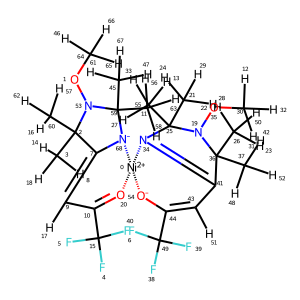

['Ni', 'O', 'C', 'C', 'F', 'F', 'F', 'C', 'H', 'C', 'C', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'N', 'O', 'C', 'H', 'H', 'H', 'C', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'N', 'O', 'C', 'C', 'F', 'F', 'F', 'C', 'H', 'C', 'C', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'N', 'O', 'C', 'H', 'H', 'H', 'C', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'N']
smiles_2='[H]C1=C(C(F)(F)F)[O-]~[Ni+2]2(~O=C(C(F)(F)F)C([H])=C3[N-]~2C(C([H])([H])[H])(C([H])([H])[H])N(OC([H])([H])[H])C3(C([H])([H])[H])C([H])([H])[H])~N2=C1C(C([H])([H])[H])(C([H])([H])[H])N(OC([H])([H])[H])C2(C([H])([H])[H])C([H])([H])[H]'
True
mol.formula='H32-C22-N4-O4-F6-Ni' smiles='[H]C1=C2[N-](~[Ni+2]3(~O=C1C(F)(F)F)~O=C(C(F)(F)F)C([H])=C1[N-]~3C(C([H])([H])[H])(C([H])([H])[H])N(OC([H])([H])[H])C1(C([H])([H])[H])C([H])([H])[H])C(C([H])([H])[H])(C([H])([H])[H])N(OC([H])([H])[H])C2(C([H])([H])[H])C([H])([H])[H]'


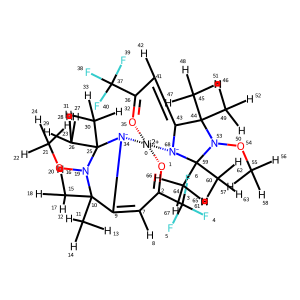

['Ni', 'O', 'C', 'C', 'F', 'F', 'F', 'C', 'H', 'C', 'C', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'N', 'O', 'C', 'H', 'H', 'H', 'C', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'N', 'O', 'C', 'C', 'F', 'F', 'F', 'C', 'H', 'C', 'C', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'N', 'O', 'C', 'H', 'H', 'H', 'C', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'N']
smiles_2='[H]C1=C2[N-](~[Ni+2]3(~O=C1C(F)(F)F)~O=C(C(F)(F)F)C([H])=C1[N-]~3C(C([H])([H])[H])(C([H])([H])[H])N(OC([H])([H])[H])C1(C([H])([H])[H])C([H])([H])[H])C(C([H])([H])[H])(C([H])([H])[H])N(OC([H])([H])[H])C2(C([H])([H])[H])C([H])([H])[H]'
True


In [40]:
for idx, mol in enumerate(cell.moleclist):
    if mol.iscomplex:
        smiles, obj = get_smiles_complex(mol, debug=1)
        print([atom.GetSymbol() for atom in obj.GetAtoms()])
        smiles_2 = Chem.MolToSmiles(obj)
        print(f"{smiles_2=}")
        print(smiles == smiles_2)
        # m = Chem.MolFromSmiles(smiles, sanitize=False)
        # display(m)